# Question 1 — monthly, quarterly and annual forecasting

This notebook contains forecasting only. Every choice is made on development data, then frozen
before the independent test is opened. Four methods are used at each frequency: seasonal/previous
period naive, Ridge Regression, Random Forest and Gradient Boosting.

> **Interpretation boundary.** Borough-month forecasts remain exploratory because the median Kish
> effective sample is small. Absolute MAE, target-specific R² and empirical error-band width must
> be read alongside improvement over the naive baseline.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'data'
RESULTS_DIR = OUTPUT_ROOT / 'results'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_PATH = DATA_DIR / 'q1_borough_monthly.csv'
QUARTERLY_PATH = DATA_DIR / 'q1_borough_quarterly.csv'
ANNUAL_PATH = DATA_DIR / 'q1_borough_annual.csv'
RESULTS_PATH = RESULTS_DIR / 'q1_forecast_results.xlsx'

TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
COMPOSITION = ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate']
CONTEXT = [
    'adult_population', 'population_age_16_34_rate', 'population_age_65_plus_rate',
    'population_female_rate', 'net_migration_per_1000',
    'median_weekly_earnings_gbp', 'earnings_relative_to_london',
    'personal_safety_crime_rate_per_1000',
    'property_public_space_crime_rate_per_1000',
    'selected_recorded_crime_rate_per_1000',
]
RANDOM_STATE = 2026
ALR_EPSILON = 1e-6


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return path


## 1. Inputs and shared feature policy

All forecasting inputs come from Notebook 01. Weather has been removed. External context is
restricted to population/migration, resident earnings and selected recorded crime, and enters only
through frequency-appropriate lags.


In [2]:
monthly = pd.read_csv(MONTHLY_PATH)
quarterly = pd.read_csv(QUARTERLY_PATH)
annual = pd.read_csv(ANNUAL_PATH)
monthly['period_start'] = pd.to_datetime(monthly['period_start'])
quarterly['quarter_start'] = pd.to_datetime(quarterly['quarter_start'])
quarterly['quarter_end'] = pd.to_datetime(quarterly['quarter_end'])

ACTIVITY = [
    column for column in monthly
    if column.startswith(('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_'))
]
assert len(ACTIVITY) == 372
assert len(monthly) == 32 * 96 and len(quarterly) == 32 * 32 and len(annual) == 32 * 8
print(f'Loaded {len(ACTIVITY)} detailed activity variables.')


Loaded 372 detailed activity variables.


## 2. Transparent modelling framework

The three shares are modelled with an additive log-ratio transform and converted back to a
composition that is non-negative and sums to one. Categorical borough identity is one-hot encoded;
all preprocessing is fitted inside each chronological fold.

For every machine-learning method, a development-only ablation compares external context on/off.
Monthly models also compare the original 372 activity variables with three auditable family means.
After the feature design is selected, four parameter settings are tried under the same rolling
folds. This separates feature and parameter decisions without touching the test period.


In [3]:
def add_compact_activity(frame):
    result = frame.copy()
    families = {
        'activity_months12_mean': 'MONTHS12_RATE_',
        'activity_days_any_mean': 'DAYS_ANY_RATE_',
        'activity_days_2plus_mean': 'DAYS_2PLUS_RATE_',
    }
    for feature, prefix in families.items():
        columns = [column for column in ACTIVITY if column.startswith(prefix)]
        result[feature] = result[columns].mean(axis=1)
    return result, list(families)


def shares_to_alr(shares):
    clipped = np.clip(np.asarray(shares, dtype=float), ALR_EPSILON, 1)
    clipped = clipped / clipped.sum(axis=1, keepdims=True)
    return np.log(clipped[:, :2] / clipped[:, [2]])


def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])


def score_predictions(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid = np.isfinite(actual).all(axis=1) & np.isfinite(predicted).all(axis=1)
    actual, predicted = actual[valid], predicted[valid]
    row = {
        'observations': len(actual),
        'total_variation': np.mean(.5 * np.abs(actual - predicted).sum(axis=1)),
        'overall_mae': np.mean(np.abs(actual - predicted)),
        'overall_rmse': np.sqrt(np.mean((actual - predicted) ** 2)),
    }
    for index, target in enumerate(TARGETS):
        row[f'{target}_mae'] = mean_absolute_error(actual[:, index], predicted[:, index])
        row[f'{target}_rmse'] = mean_squared_error(
            actual[:, index], predicted[:, index], squared=False
        )
        row[f'{target}_r2'] = r2_score(actual[:, index], predicted[:, index])
    return row


def prepare_panel(frame, time_column, cycle_column, cycle_length, lag):
    prepared, compact = add_compact_activity(frame)
    prepared = prepared.sort_values(['geography_code', time_column]).reset_index(drop=True)
    source_columns = TARGETS + COMPOSITION + ACTIVITY + compact + CONTEXT
    grouped = prepared.groupby('geography_code', sort=False)
    for column in source_columns:
        prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
    phase = 2 * np.pi * (prepared[cycle_column] - 1) / cycle_length
    prepared['season_sin'] = np.sin(phase)
    prepared['season_cos'] = np.cos(phase)
    prepared['time_trend'] = prepared[time_column] / prepared[time_column].max()
    return prepared, compact


def feature_sets(lag, compact):
    common = [f'{column}_lag{lag}' for column in TARGETS + COMPOSITION]
    calendar = ['season_sin', 'season_cos', 'time_trend']
    detailed = [f'{column}_lag{lag}' for column in ACTIVITY]
    compact_lagged = [f'{column}_lag{lag}' for column in compact]
    context = [f'{column}_lag{lag}' for column in CONTEXT]
    return {
        'detailed_with_context': common + detailed + context + calendar,
        'detailed_without_context': common + detailed + calendar,
        'compact_with_context': common + compact_lagged + context + calendar,
        'compact_without_context': common + compact_lagged + calendar,
    }


def parameter_candidates(model_name):
    if model_name == 'Ridge Regression':
        return [
            {'alpha': .1}, {'alpha': 1.0}, {'alpha': 10.0}, {'alpha': 100.0},
        ]
    if model_name == 'Random Forest':
        return [
            {'n_estimators': 160, 'max_depth': 6, 'min_samples_leaf': 5, 'max_features': .5},
            {'n_estimators': 160, 'max_depth': 10, 'min_samples_leaf': 8, 'max_features': .5},
            {'n_estimators': 220, 'max_depth': 8, 'min_samples_leaf': 12, 'max_features': .8},
            {'n_estimators': 220, 'max_depth': None, 'min_samples_leaf': 15, 'max_features': .4},
        ]
    return [
        {'n_estimators': 120, 'learning_rate': .03, 'max_depth': 2, 'min_samples_leaf': 10},
        {'n_estimators': 160, 'learning_rate': .03, 'max_depth': 2, 'min_samples_leaf': 20},
        {'n_estimators': 120, 'learning_rate': .05, 'max_depth': 3, 'min_samples_leaf': 15},
        {'n_estimators': 200, 'learning_rate': .02, 'max_depth': 2, 'min_samples_leaf': 15},
    ]


def build_model(model_name, parameters, numeric_features):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'Ridge Regression':
        numeric_steps.append(('scale', StandardScaler()))
    preprocess = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric_features),
        ('borough', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['geography_code']),
    ])
    if model_name == 'Ridge Regression':
        estimator = Ridge(**parameters)
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(
            **parameters, random_state=RANDOM_STATE, n_jobs=-1
        )
    else:
        estimator = MultiOutputRegressor(GradientBoostingRegressor(
            **parameters, random_state=RANDOM_STATE, loss='huber'
        ))
    return Pipeline([('preprocess', preprocess), ('model', estimator)])


def naive_predict(frame, lag):
    return frame[[f'{target}_lag{lag}' for target in TARGETS]].to_numpy()


def cv_evaluate(panel, time_column, folds, lag, model_name, features=None, parameters=None):
    metric_rows, prediction_rows = [], []
    for fold_id, (validation_start, validation_end) in enumerate(folds, start=1):
        train = panel.loc[panel[time_column].lt(validation_start)].dropna(subset=TARGETS)
        validation = panel.loc[panel[time_column].between(validation_start, validation_end)].dropna(
            subset=TARGETS
        )
        if model_name == 'Naive baseline':
            predicted = naive_predict(validation, lag)
        else:
            model = build_model(model_name, parameters, features)
            model.fit(train[features + ['geography_code']], shares_to_alr(train[TARGETS]))
            predicted = alr_to_shares(model.predict(validation[features + ['geography_code']]))
        metrics = score_predictions(validation[TARGETS], predicted)
        metric_rows.append({'fold': fold_id, 'validation_start': validation_start,
                            'validation_end': validation_end, **metrics})
        output = validation[[time_column, 'geography_code', 'geography_name', *TARGETS]].copy()
        output['fold'] = fold_id
        for index, target in enumerate(TARGETS):
            output[f'predicted_{target}'] = predicted[:, index]
        prediction_rows.append(output)
    return pd.DataFrame(metric_rows), pd.concat(prediction_rows, ignore_index=True)


def run_frequency_selection(label, panel, time_column, folds, test_start, lag, configurations):
    model_names = ['Ridge Regression', 'Random Forest', 'Gradient Boosting']
    ablation_rows, tuning_rows, registry_rows = [], [], []
    selected = {}
    default_parameters = {name: parameter_candidates(name)[1] for name in model_names}

    for model_name in model_names:
        for configuration, features in configurations.items():
            fold_metrics, _ = cv_evaluate(
                panel, time_column, folds, lag, model_name, features, default_parameters[model_name]
            )
            ablation_rows.append({
                'frequency': label, 'model': model_name, 'configuration': configuration,
                'numeric_features': len(features),
                'mean_cv_total_variation': fold_metrics['total_variation'].mean(),
                'sd_cv_total_variation': fold_metrics['total_variation'].std(ddof=1),
            })
        model_ablation = pd.DataFrame(ablation_rows).loc[lambda x: x['model'].eq(model_name)]
        best_configuration = model_ablation.sort_values('mean_cv_total_variation').iloc[0]['configuration']
        best_features = configurations[best_configuration]
        for parameters in parameter_candidates(model_name):
            fold_metrics, _ = cv_evaluate(
                panel, time_column, folds, lag, model_name, best_features, parameters
            )
            tuning_rows.append({
                'frequency': label, 'model': model_name,
                'configuration': best_configuration,
                'parameters': json.dumps(parameters, sort_keys=True),
                'mean_cv_total_variation': fold_metrics['total_variation'].mean(),
                'sd_cv_total_variation': fold_metrics['total_variation'].std(ddof=1),
            })
        tuning_model = pd.DataFrame(tuning_rows).loc[lambda x: x['model'].eq(model_name)]
        best_tuning = tuning_model.sort_values(
            ['mean_cv_total_variation', 'sd_cv_total_variation']
        ).iloc[0]
        selected[model_name] = {
            'configuration': best_configuration,
            'features': best_features,
            'parameters': json.loads(best_tuning['parameters']),
        }

    cv_metrics_parts, cv_prediction_parts = [], []
    naive_metrics, naive_predictions = cv_evaluate(
        panel, time_column, folds, lag, 'Naive baseline'
    )
    naive_metrics['model'] = 'Naive baseline'
    naive_predictions['model'] = 'Naive baseline'
    cv_metrics_parts.append(naive_metrics)
    cv_prediction_parts.append(naive_predictions)

    for model_name, specification in selected.items():
        fold_metrics, fold_predictions = cv_evaluate(
            panel, time_column, folds, lag, model_name,
            specification['features'], specification['parameters']
        )
        fold_metrics['model'] = model_name
        fold_predictions['model'] = model_name
        cv_metrics_parts.append(fold_metrics)
        cv_prediction_parts.append(fold_predictions)
        registry_rows.append({
            'frequency': label, 'model': model_name,
            'configuration': specification['configuration'],
            'numeric_features': len(specification['features']),
            'feature_names': json.dumps(specification['features']),
            'parameters': json.dumps(specification['parameters'], sort_keys=True),
        })

    cv_metrics = pd.concat(cv_metrics_parts, ignore_index=True)
    cv_predictions = pd.concat(cv_prediction_parts, ignore_index=True)
    summary = cv_metrics.groupby('model', as_index=False).agg(
        mean_cv_total_variation=('total_variation', 'mean'),
        sd_cv_total_variation=('total_variation', 'std'),
        mean_cv_mae=('overall_mae', 'mean'),
    ).sort_values(['mean_cv_total_variation', 'sd_cv_total_variation'])
    selected_model = summary.iloc[0]['model']

    test = panel.loc[panel[time_column].ge(test_start)].dropna(subset=TARGETS)
    train = panel.loc[panel[time_column].lt(test_start)].dropna(subset=TARGETS)
    test_metrics_rows, test_prediction_parts, fitted = [], [], {}
    for model_name in ['Naive baseline', *selected]:
        if model_name == 'Naive baseline':
            predicted = naive_predict(test, lag)
        else:
            specification = selected[model_name]
            model = build_model(model_name, specification['parameters'], specification['features'])
            model.fit(
                train[specification['features'] + ['geography_code']],
                shares_to_alr(train[TARGETS]),
            )
            predicted = alr_to_shares(
                model.predict(test[specification['features'] + ['geography_code']])
            )
            fitted[model_name] = model
        test_metrics_rows.append({'frequency': label, 'model': model_name,
                                  **score_predictions(test[TARGETS], predicted)})
        output = test[[time_column, 'geography_code', 'geography_name', *TARGETS]].copy()
        output['model'] = model_name
        for index, target in enumerate(TARGETS):
            output[f'predicted_{target}'] = predicted[:, index]
        test_prediction_parts.append(output)

    test_metrics = pd.DataFrame(test_metrics_rows)
    test_predictions = pd.concat(test_prediction_parts, ignore_index=True)
    registry_rows.append({
        'frequency': label, 'model': 'Naive baseline', 'configuration': 'seasonal lag',
        'numeric_features': len(TARGETS),
        'feature_names': json.dumps([f'{target}_lag{lag}' for target in TARGETS]),
        'parameters': '{}',
    })
    return {
        'ablation': pd.DataFrame(ablation_rows), 'tuning': pd.DataFrame(tuning_rows),
        'cv_metrics': cv_metrics, 'cv_predictions': cv_predictions,
        'cv_summary': summary, 'selected_model': selected_model,
        'test_metrics': test_metrics, 'test_predictions': test_predictions,
        'registry': pd.DataFrame(registry_rows), 'specifications': selected, 'fitted': fitted,
    }


## 3. Monthly forecasting

Twelve-month lags preserve seasonality. Months 49–84 form three expanding validation blocks and
Months 85–96 are the untouched final-year test. The naive model repeats the same borough’s values
from twelve months earlier.


In [4]:
monthly_model, monthly_compact = prepare_panel(
    monthly, 'month_index', 'month_of_wave', 12, lag=12
)
monthly_features = feature_sets(12, monthly_compact)
MONTHLY_FOLDS = [(49, 60), (61, 72), (73, 84)]
monthly_results = run_frequency_selection(
    'Monthly', monthly_model, 'month_index', MONTHLY_FOLDS, test_start=85,
    lag=12, configurations=monthly_features,
)
display(monthly_results['ablation'].sort_values(['model', 'mean_cv_total_variation']))
display(monthly_results['cv_summary'])
display(monthly_results['test_metrics'].sort_values('total_variation'))
print(f"Development-selected monthly model: {monthly_results['selected_model']}")


C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,frequency,model,configuration,numeric_features,mean_cv_total_variation,sd_cv_total_variation
10,Monthly,Gradient Boosting,compact_with_context,22,0.107733,0.005484
8,Monthly,Gradient Boosting,detailed_with_context,391,0.108099,0.005511
9,Monthly,Gradient Boosting,detailed_without_context,381,0.108409,0.005822
11,Monthly,Gradient Boosting,compact_without_context,12,0.108737,0.005990
5,Monthly,Random Forest,detailed_without_context,381,0.131054,0.032037
4,Monthly,Random Forest,detailed_with_context,391,0.132546,0.027533
6,Monthly,Random Forest,compact_with_context,22,0.134553,0.026999
7,Monthly,Random Forest,compact_without_context,12,0.138053,0.037348
3,Monthly,Ridge Regression,compact_without_context,12,0.116868,0.005610
2,Monthly,Ridge Regression,compact_with_context,22,0.121601,0.005454


,model,mean_cv_total_variation,sd_cv_total_variation,mean_cv_mae
0,Gradient Boosting,0.107733,0.005484,0.071822
3,Ridge Regression,0.115641,0.005662,0.077094
2,Random Forest,0.127654,0.027031,0.085103
1,Naive baseline,0.147576,0.003840,0.098384


,frequency,model,observations,total_variation,overall_mae,overall_rmse,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,active_rate_mae,active_rate_rmse,active_rate_r2
3,Monthly,Gradient Boosting,384,0.103215,0.068810,0.090878,0.074636,0.098064,0.166656,0.046695,0.060514,-0.020221,0.085099,0.107228,0.172702
1,Monthly,Ridge Regression,384,0.106860,0.071240,0.093854,0.073591,0.095956,0.202099,0.051912,0.070154,-0.371159,0.088216,0.110891,0.115218
2,Monthly,Random Forest,384,0.110533,0.073689,0.097481,0.078871,0.101430,0.108471,0.050077,0.067212,-0.258573,0.092118,0.117056,0.014101
0,Monthly,Naive baseline,384,0.143909,0.095939,0.122994,0.105654,0.132322,-0.517288,0.067561,0.086273,-1.073651,0.114603,0.142935,-0.470016


Development-selected monthly model: Gradient Boosting


### COVID and empirical error bands

COVID-period error is reported separately rather than pooled silently with ordinary months. The
90% bands use the development residual distribution and are deliberately named **empirical error
bands**: they are not model quantiles or fully calibrated probability intervals.


In [5]:
monthly_selected_cv = monthly_results['cv_predictions'].loc[
    lambda frame: frame['model'].eq(monthly_results['selected_model'])
].copy()
monthly_selected_cv = monthly_selected_cv.merge(
    monthly[['month_index', 'geography_code', 'period_start', 'effective_n']],
    on=['month_index', 'geography_code'], validate='one_to_one',
)
monthly_selected_cv['covid_period'] = monthly_selected_cv['period_start'].between(
    '2020-03-01', '2021-07-01'
)
monthly_selected_cv['row_total_variation'] = .5 * sum(
    (monthly_selected_cv[target] - monthly_selected_cv[f'predicted_{target}']).abs()
    for target in TARGETS
)
monthly_covid_diagnostic = monthly_selected_cv.groupby('covid_period', as_index=False).agg(
    observations=('row_total_variation', 'size'),
    mean_total_variation=('row_total_variation', 'mean'),
    median_effective_n=('effective_n', 'median'),
)

monthly_selected_test = monthly_results['test_predictions'].loc[
    lambda frame: frame['model'].eq(monthly_results['selected_model'])
].copy()
for target in TARGETS:
    calibration_radius = np.quantile(
        np.abs(monthly_selected_cv[target] - monthly_selected_cv[f'predicted_{target}']), .90
    )
    monthly_selected_test[f'empirical_band_low_{target}'] = np.clip(
        monthly_selected_test[f'predicted_{target}'] - calibration_radius, 0, 1
    )
    monthly_selected_test[f'empirical_band_high_{target}'] = np.clip(
        monthly_selected_test[f'predicted_{target}'] + calibration_radius, 0, 1
    )
display(monthly_covid_diagnostic)


,covid_period,observations,mean_total_variation,median_effective_n
0,False,608,0.100180,25.498805
1,True,543,0.116179,25.390147


## 4. Direct quarterly forecasting

Quarterly targets are direct `wt_time` survey estimates from Notebook 01. Four-quarter lags and
three four-quarter validation blocks mirror the monthly design. Compact activity features are the
default here because the direct quarterly training sample is smaller and the detailed activity
variables are highly correlated.


In [6]:
quarterly_model, quarterly_compact = prepare_panel(
    quarterly, 'quarter_index', 'quarter_of_wave', 4, lag=4
)
quarterly_all_features = feature_sets(4, quarterly_compact)
quarterly_features = {
    key: value for key, value in quarterly_all_features.items() if key.startswith('compact_')
}
QUARTERLY_FOLDS = [(17, 20), (21, 24), (25, 28)]
quarterly_results = run_frequency_selection(
    'Quarterly', quarterly_model, 'quarter_index', QUARTERLY_FOLDS, test_start=29,
    lag=4, configurations=quarterly_features,
)
display(quarterly_results['ablation'].sort_values(['model', 'mean_cv_total_variation']))
display(quarterly_results['cv_summary'])
display(quarterly_results['test_metrics'].sort_values('total_variation'))
print(f"Development-selected direct quarterly model: {quarterly_results['selected_model']}")


C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,frequency,model,configuration,numeric_features,mean_cv_total_variation,sd_cv_total_variation
4,Quarterly,Gradient Boosting,compact_with_context,22,0.066630,0.005646
5,Quarterly,Gradient Boosting,compact_without_context,12,0.067184,0.004865
2,Quarterly,Random Forest,compact_with_context,22,0.068775,0.004240
3,Quarterly,Random Forest,compact_without_context,12,0.069218,0.005150
1,Quarterly,Ridge Regression,compact_without_context,12,0.066290,0.006921
0,Quarterly,Ridge Regression,compact_with_context,22,0.070789,0.007692


,model,mean_cv_total_variation,sd_cv_total_variation,mean_cv_mae
3,Ridge Regression,0.066247,0.006784,0.044165
0,Gradient Boosting,0.066402,0.005550,0.044268
2,Random Forest,0.068084,0.005321,0.045389
1,Naive baseline,0.086933,0.002413,0.057956


,frequency,model,observations,total_variation,overall_mae,overall_rmse,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,active_rate_mae,active_rate_rmse,active_rate_r2
1,Quarterly,Ridge Regression,128,0.065839,0.043892,0.057349,0.048050,0.062307,0.400478,0.027823,0.035013,-0.021465,0.055804,0.068981,0.414131
3,Quarterly,Gradient Boosting,128,0.068804,0.045869,0.060188,0.051766,0.065953,0.328267,0.027944,0.034504,0.008050,0.057898,0.072989,0.344088
2,Quarterly,Random Forest,128,0.070935,0.047290,0.063347,0.054416,0.070712,0.227820,0.027328,0.033914,0.041678,0.060126,0.076734,0.275047
0,Quarterly,Naive baseline,128,0.087629,0.058419,0.076794,0.064154,0.082252,-0.044760,0.039576,0.052165,-1.267349,0.071527,0.090584,-0.010279


Development-selected direct quarterly model: Ridge Regression


## 5. Select monthly or quarterly resolution

The selected monthly model is averaged to quarters and compared with the direct quarterly model
against the same direct quarterly truth. The development comparison alone chooses the preferred
resolution; the four-quarter test is reported afterwards. This makes the contest fair and prevents
the test result from deciding the model.


In [7]:
def aggregate_monthly_prediction_to_quarter(predictions):
    result = predictions.copy()
    result['quarter_index'] = ((result['month_index'] - 1) // 3 + 1).astype(int)
    columns = [f'predicted_{target}' for target in TARGETS]
    return result.groupby(['quarter_index', 'geography_code', 'geography_name'], as_index=False)[
        columns
    ].mean()


quarter_truth = quarterly[['quarter_index', 'geography_code', 'geography_name', *TARGETS]]
monthly_to_quarter_cv = aggregate_monthly_prediction_to_quarter(monthly_selected_cv).merge(
    quarter_truth, on=['quarter_index', 'geography_code', 'geography_name'], validate='one_to_one'
)
monthly_to_quarter_test = aggregate_monthly_prediction_to_quarter(monthly_selected_test).merge(
    quarter_truth, on=['quarter_index', 'geography_code', 'geography_name'], validate='one_to_one'
)
quarter_selected_cv = quarterly_results['cv_predictions'].loc[
    lambda frame: frame['model'].eq(quarterly_results['selected_model'])
]
quarter_selected_test = quarterly_results['test_predictions'].loc[
    lambda frame: frame['model'].eq(quarterly_results['selected_model'])
]

resolution_rows = []
for phase, candidates in {
    'Development CV': {
        'Monthly model aggregated to quarter': monthly_to_quarter_cv,
        'Direct quarterly model': quarter_selected_cv,
    },
    'Independent test': {
        'Monthly model aggregated to quarter': monthly_to_quarter_test,
        'Direct quarterly model': quarter_selected_test,
    },
}.items():
    for approach, frame in candidates.items():
        predicted = frame[[f'predicted_{target}' for target in TARGETS]].to_numpy()
        resolution_rows.append({'phase': phase, 'approach': approach,
                                **score_predictions(frame[TARGETS], predicted)})
resolution_comparison = pd.DataFrame(resolution_rows)
development_resolution = resolution_comparison.loc[
    resolution_comparison['phase'].eq('Development CV')
].sort_values('total_variation').iloc[0]['approach']
selected_resolution = (
    'Quarterly' if development_resolution == 'Direct quarterly model' else 'Monthly'
)
resolution_test_predictions = (
    quarter_selected_test.copy()
    if selected_resolution == 'Quarterly' else monthly_to_quarter_test.copy()
)
display(resolution_comparison)
print(f'Development-only frequency decision: {development_resolution}')


,phase,approach,observations,total_variation,overall_mae,overall_rmse,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,active_rate_mae,active_rate_rmse,active_rate_r2
0,Development CV,Monthly model aggregated to quarter,384,0.069744,0.046496,0.060433,0.049549,0.063020,0.215858,0.030972,0.039205,-0.035412,0.058968,0.073810,0.214530
1,Development CV,Direct quarterly model,384,0.066247,0.044165,0.057382,0.047648,0.060758,0.271144,0.029597,0.037582,0.048574,0.055250,0.069095,0.311663
2,Independent test,Monthly model aggregated to quarter,128,0.068701,0.045801,0.061218,0.050786,0.065932,0.328698,0.027794,0.035359,-0.041725,0.058822,0.075137,0.304903
3,Independent test,Direct quarterly model,128,0.065839,0.043892,0.057349,0.048050,0.062307,0.400478,0.027823,0.035013,-0.021465,0.055804,0.068981,0.414131


Development-only frequency decision: Direct quarterly model


## 6. Annual forecast

Years 1–6 train the candidates, Year 7 selects features, parameters and algorithm, and Year 8 is
the independent test. Annual selection is fully decoupled from monthly decisions. Compact activity
features are used because only 160 lagged training observations are available through Year 6.


In [8]:
annual_model, annual_compact = prepare_panel(
    annual, 'year', 'year', 1, lag=1
)
annual_all_features = feature_sets(1, annual_compact)
annual_features = {
    key: value for key, value in annual_all_features.items() if key.startswith('compact_')
}
ANNUAL_FOLDS = [(7, 7)]
annual_results = run_frequency_selection(
    'Annual', annual_model, 'year', ANNUAL_FOLDS, test_start=8,
    lag=1, configurations=annual_features,
)
display(annual_results['ablation'].sort_values(['model', 'mean_cv_total_variation']))
display(annual_results['cv_summary'])
display(annual_results['test_metrics'].sort_values('total_variation'))
print(f"Year-7-selected annual model: {annual_results['selected_model']}")


C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
C:\Users\eik\AppData\Local\Temp\ipykernel_20432\812980621.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,frequency,model,configuration,numeric_features,mean_cv_total_variation,sd_cv_total_variation
4,Annual,Gradient Boosting,compact_with_context,22,0.036719,NaN
5,Annual,Gradient Boosting,compact_without_context,12,0.041584,NaN
2,Annual,Random Forest,compact_with_context,22,0.034633,NaN
3,Annual,Random Forest,compact_without_context,12,0.039415,NaN
0,Annual,Ridge Regression,compact_with_context,22,0.041694,NaN
1,Annual,Ridge Regression,compact_without_context,12,0.052088,NaN


,model,mean_cv_total_variation,sd_cv_total_variation,mean_cv_mae
2,Random Forest,0.033892,NaN,0.022595
3,Ridge Regression,0.034939,NaN,0.023293
0,Gradient Boosting,0.036532,NaN,0.024355
1,Naive baseline,0.038817,NaN,0.025878


,frequency,model,observations,total_variation,overall_mae,overall_rmse,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,active_rate_mae,active_rate_rmse,active_rate_r2
3,Annual,Gradient Boosting,32,0.035988,0.023992,0.032226,0.029479,0.038799,0.546640,0.013375,0.016453,-0.100382,0.029122,0.036598,0.671584
1,Annual,Ridge Regression,32,0.036515,0.024344,0.033679,0.028979,0.039046,0.540848,0.011083,0.014260,0.173377,0.032968,0.040926,0.589323
2,Annual,Random Forest,32,0.039478,0.026319,0.035958,0.032901,0.042763,0.449263,0.014270,0.017988,-0.315305,0.031785,0.041553,0.576645
0,Annual,Naive baseline,32,0.043149,0.028766,0.036393,0.033084,0.040204,0.513224,0.019409,0.024009,-1.343323,0.033806,0.042198,0.563401


Year-7-selected annual model: Random Forest


## 7. Decision-focused visual summary

The plots show development performance, the same-quarter resolution contest and the untouched
annual/test forecasts. Test bars are descriptive only and never feed back into selection.


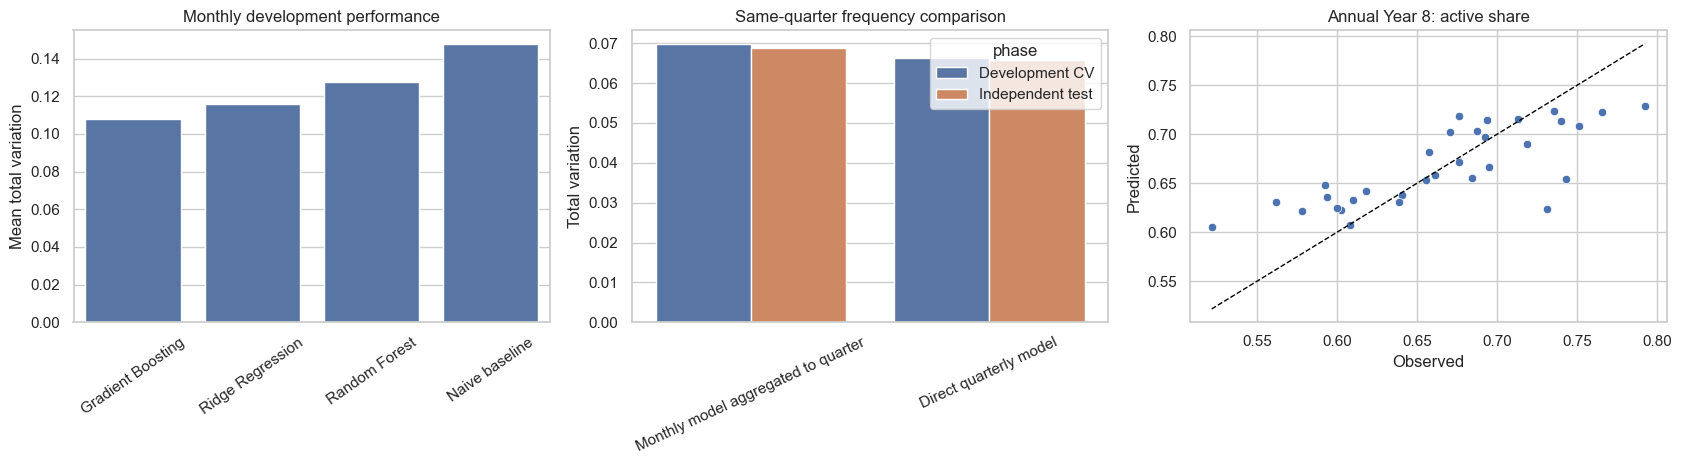

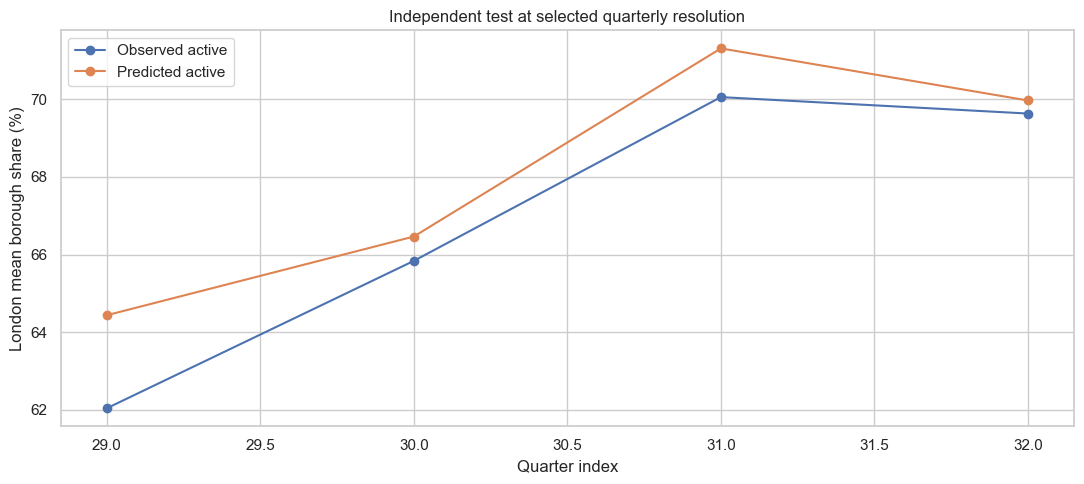

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
monthly_summary = monthly_results['cv_summary'].copy()
sns.barplot(data=monthly_summary, x='model', y='mean_cv_total_variation', ax=axes[0], color='#4c72b0')
axes[0].set(title='Monthly development performance', xlabel='', ylabel='Mean total variation')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(data=resolution_comparison, x='approach', y='total_variation', hue='phase', ax=axes[1])
axes[1].set(title='Same-quarter frequency comparison', xlabel='', ylabel='Total variation')
axes[1].tick_params(axis='x', rotation=25)

annual_test_plot = annual_results['test_predictions'].loc[
    lambda frame: frame['model'].eq(annual_results['selected_model'])
]
sns.scatterplot(data=annual_test_plot, x='active_rate', y='predicted_active_rate', ax=axes[2])
limit = [annual_test_plot[['active_rate', 'predicted_active_rate']].min().min(),
         annual_test_plot[['active_rate', 'predicted_active_rate']].max().max()]
axes[2].plot(limit, limit, '--', color='black', linewidth=1)
axes[2].set(title='Annual Year 8: active share', xlabel='Observed', ylabel='Predicted')
fig.tight_layout()
save_figure(fig, 'forecast_model_and_frequency_comparison.png')
plt.show()

selected_test_plot = resolution_test_predictions.groupby('quarter_index', as_index=False)[
    [*TARGETS, *[f'predicted_{target}' for target in TARGETS]]
].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(selected_test_plot['quarter_index'], selected_test_plot['active_rate'] * 100,
        marker='o', label='Observed active')
ax.plot(selected_test_plot['quarter_index'], selected_test_plot['predicted_active_rate'] * 100,
        marker='o', label='Predicted active')
ax.set(title=f'Independent test at selected {selected_resolution.lower()} resolution',
       xlabel='Quarter index', ylabel='London mean borough share (%)')
ax.legend()
fig.tight_layout()
save_figure(fig, 'selected_frequency_test_forecast.png')
plt.show()


## 8. Compact delivery and reproducibility

All ablations, tuning trials, fold predictions, holdout predictions and model specifications are
stored as sheets in one workbook. The registry records exact features and parameters so Notebook
04 can refit the selected model for explainability without proliferating intermediate CSV files.


In [10]:
model_registry = pd.concat([
    monthly_results['registry'], quarterly_results['registry'], annual_results['registry']
], ignore_index=True)
selection_register = pd.DataFrame([
    {'task': 'Monthly', 'selected_model': monthly_results['selected_model'],
     'selection_data': 'Months 49-84 rolling development CV'},
    {'task': 'Quarterly', 'selected_model': quarterly_results['selected_model'],
     'selection_data': 'Quarters 17-28 rolling development CV'},
    {'task': 'Monthly versus quarterly', 'selected_model': development_resolution,
     'selection_data': 'Same-quarter development CV targets'},
    {'task': 'Annual', 'selected_model': annual_results['selected_model'],
     'selection_data': 'Year 7 validation only'},
])

with pd.ExcelWriter(RESULTS_PATH, engine='openpyxl') as writer:
    for prefix, result in [
        ('monthly', monthly_results), ('quarterly', quarterly_results), ('annual', annual_results)
    ]:
        result['ablation'].to_excel(writer, sheet_name=f'{prefix}_feature_ablation', index=False)
        result['tuning'].to_excel(writer, sheet_name=f'{prefix}_tuning', index=False)
        result['cv_metrics'].to_excel(writer, sheet_name=f'{prefix}_cv_metrics', index=False)
        result['cv_predictions'].to_excel(writer, sheet_name=f'{prefix}_cv_predictions', index=False)
        result['test_metrics'].to_excel(writer, sheet_name=f'{prefix}_test_metrics', index=False)
        result['test_predictions'].to_excel(writer, sheet_name=f'{prefix}_test_predictions', index=False)
    monthly_covid_diagnostic.to_excel(writer, sheet_name='monthly_covid_diagnostic', index=False)
    monthly_selected_test.to_excel(writer, sheet_name='monthly_selected_with_bands', index=False)
    resolution_comparison.to_excel(writer, sheet_name='resolution_comparison', index=False)
    resolution_test_predictions.to_excel(writer, sheet_name='selected_resolution_test', index=False)
    model_registry.to_excel(writer, sheet_name='model_registry', index=False)
    selection_register.to_excel(writer, sheet_name='selection_register', index=False)

print(f'Wrote {RESULTS_PATH.relative_to(PROJECT_ROOT)}')


Wrote question1_outputs\results\q1_forecast_results.xlsx
